# 1D Diffusion Equation Simulation

## Import Library

In [15]:
import numpy as np
import matplotlib.pyplot as plt

## Setup the Domain

Grid spacing (dx): 0.01
Time step size (dt): 0.005
Total simulation time (T): 1.0


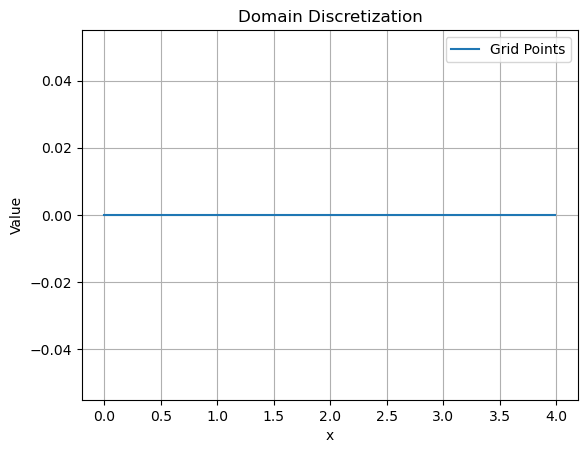

In [16]:
L = 4 # Length of the domain
N = 400 # Number of grid points

dx = L / N # Grid spacing

print("Grid spacing (dx):", dx)

x = np.linspace(0, L, N, endpoint=False)

alpha = 0.01 # Diffusion coefficient
r = 0.5 # Stability parameter

dt = r * dx**2 / alpha # Time step size
print("Time step size (dt):", dt)

nt = 200 # Number of time steps
T = nt * dt # Total simulation time
print("Total simulation time (T):", T)

plt.plot(x, np.zeros_like(x), label='Grid Points')
plt.title('Domain Discretization')
plt.xlabel('x')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

## Initial Setup

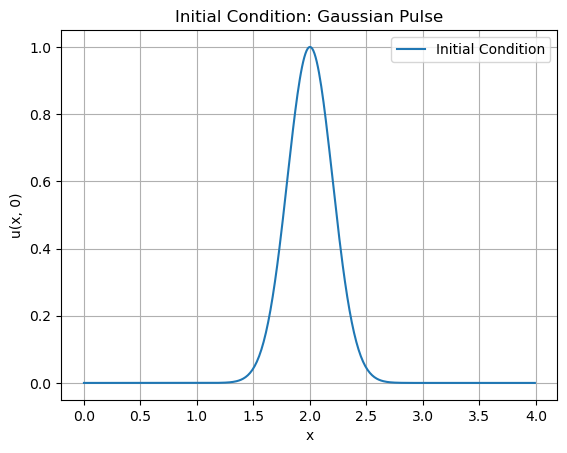

In [17]:
x0 = L / 2 # Initial position of the pulse
sigma = 0.2 # Width of the pulse

u0 = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2)) # Initial condition
plt.plot(x, u0, label='Initial Condition')
plt.title('Initial Condition: Gaussian Pulse')
plt.xlabel('x')
plt.ylabel('u(x, 0)')
plt.legend()
plt.grid()
plt.show()

## Solve the Explicit - FTCS

In [18]:
def diffusion_ftcs(u, r):
    u_left  = np.roll(u, 1)   # u_{i-1} for all i, wraps u[0] → u[-1] (periodic BC)
    u_right = np.roll(u, -1)  # u_{i+1} for all i, wraps u[-1] → u[0] (periodic BC)
    return u + r * (u_left - 2 * u + u_right) # FTCS scheme for diffusion

u = np.copy(u0) # Initialize the solution with the initial condition
u_history = [u.copy()] # Store the solution history for plotting
for n in range(nt):
    u = diffusion_ftcs(u, r) # Update the solution using the FTCS scheme
    u_history.append(u.copy()) # Store the solution at each time step

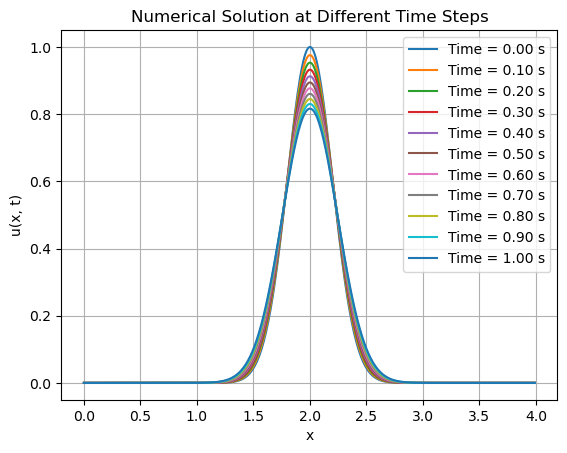

In [19]:
u_exact = np.exp(-((x - x0) ** 2) / (2 * (sigma**2 + 2 * alpha * T))) # Exact solution at time T

for n in range(0, nt + 1, 20):
    plt.plot(x, u_history[n], label=f'Time = {n*dt:.2f} s')
plt.title('Numerical Solution at Different Time Steps')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()

## Solve Implicit Scheme - BTCS

In [20]:
# BTCS scheme implementation - implicit method for diffusion equation (A*U = U_old)
def diffusion_btcs(u, r):
    A = np.zeros((N, N))
    np.fill_diagonal(A, 1 + 2 * r)
    np.fill_diagonal(A[1:], -r)
    np.fill_diagonal(A[:, 1:], -r)
    A[0, -1] = -r # Periodic boundary condition
    A[-1, 0] = -r # Periodic boundary condition
    u_new = np.linalg.solve(A, u) # Solve the linear system A * u_new = u
    return u_new

u = np.copy(u0) # Initialize the solution with the initial condition
u_history_btcs = [u.copy()] # Store the solution history for plotting
for n in range(nt):
    u = diffusion_btcs(u, r) # Update the solution using the BTCS scheme
    u_history_btcs.append(u.copy()) # Store the solution at each time step

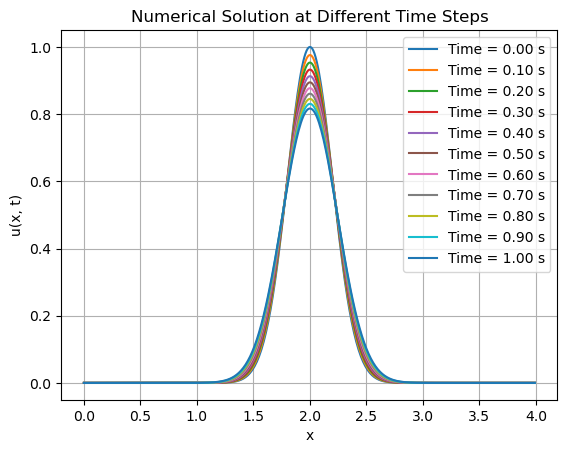

In [21]:
u_exact = np.exp(-((x - x0) ** 2) / (2 * (sigma**2 + 2 * alpha * T))) # Exact solution at time T

for n in range(0, nt + 1, 20):
    plt.plot(x, u_history_btcs[n], label=f'Time = {n*dt:.2f} s')
plt.title('Numerical Solution at Different Time Steps')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()